# IDS Challenge: Sub-Project 02 Data Science
## Results 

### Group: ___
### Tutor: ___

This is your workspace - implement all submission-relevant functions and elements here and add short text-descriptions that explain your steps. (See `README_EN.ipynb`)

## 1. Data analysis


For the biggining of the code I had some problems, with accessing the the wanted file, so I had to debugg a bit the blueprint. Also changed the name `dataframe` into `raw_train_df` so we don't have such a generic name in the code

In [3]:
import pandas as pd
import seaborn as snsraw_train_df
from matplotlib import pyplot as plt

RANDOM_STATE = 23
TRAIN_FILE = "production_dataset/robot_energy_train.csv"
UNLABELED_FILE = "production_dataset/robot_energy_unlabeled.csv"

raw_train_df = pd.read_csv(TRAIN_FILE)
raw_train_df.head()

,Mission ID,Distance [m],Elevation [m],Cargo [kg],Battery Level,Time of Day [h],Traffic Level,Mode,Energy [kJ]
0,1096,163.63,-2.6,6.13,0.774,15.0,low,normal,567.657
1,1097,261.42,-1.5,2.58,0.893,12.0,medium,normal,558.238
2,1098,145.91,0.2,4.96,0.659,3.0,low,priority,317.912
3,1099,58.00,1.0,0.00,0.690,5.0,low,normal,134.379
4,1100,272.79,0.3,2.59,0.759,2.0,low,normal,431.359


In [4]:
raw_train_df.info()
raw_train_df.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Mission ID       4000 non-null   int64  
 1   Distance [m]     3940 non-null   float64
 2   Elevation [m]    3940 non-null   float64
 3   Cargo [kg]       3940 non-null   float64
 4   Battery Level    3940 non-null   float64
 5   Time of Day [h]  3940 non-null   float64
 6   Traffic Level    3940 non-null   str    
 7   Mode             3940 non-null   str    
 8   Energy [kJ]      4000 non-null   float64
dtypes: float64(6), int64(1), str(2)
memory usage: 281.4 KB


,Mission ID,Distance [m],Elevation [m],Cargo [kg],Battery Level,Time of Day [h],Traffic Level,Mode,Energy [kJ]
count,4000.000000,3940.000000,3940.000000,3940.000000,3940.000000,3940.000000,3940,3940,4000.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,3,2,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,low,normal,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,1694,3157,NaN
mean,3095.500000,156.953119,0.054188,3.502345,0.685359,11.381980,NaN,NaN,411.809967
std,1154.844867,74.632542,2.264159,2.581571,0.182402,6.913643,NaN,NaN,179.102698
min,1096.000000,20.370000,-8.000000,0.000000,0.131000,0.000000,NaN,NaN,57.207000
25%,2095.750000,97.857500,-1.500000,1.377500,0.564000,5.000000,NaN,NaN,280.449250
50%,3095.500000,147.655000,0.100000,3.260000,0.709500,11.000000,NaN,NaN,391.084000
75%,4095.250000,210.512500,1.500000,5.252500,0.828000,17.000000,NaN,NaN,517.646750


In [ ]:
missing_summary = raw_train_df.isna().sum().sort_values(ascending=False)
print(missing_summary)


Distance [m]       60
Time of Day [h]    60
Elevation [m]      60
Cargo [kg]         60
Battery Level      60
Mode               60
Traffic Level      60
Mission ID          0
Energy [kJ]         0
dtype: int64


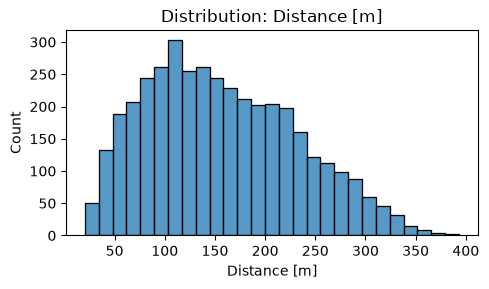

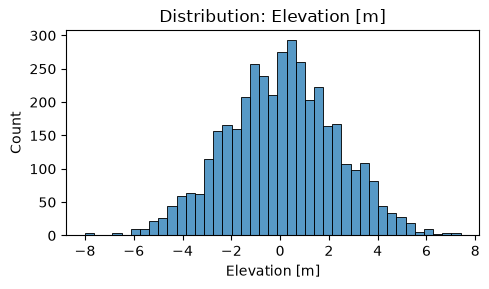

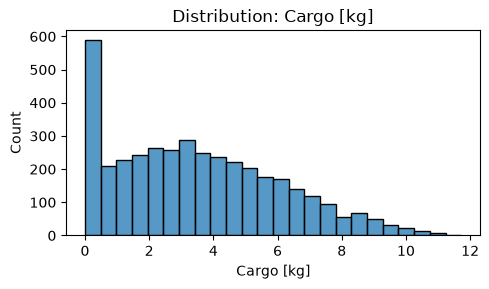

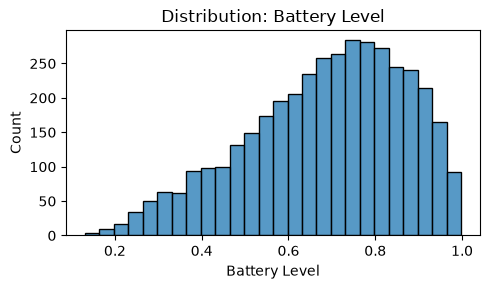

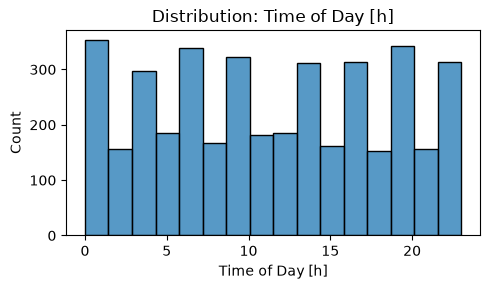

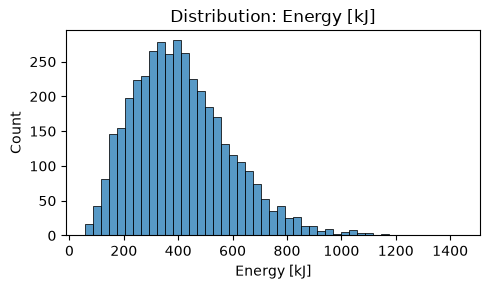

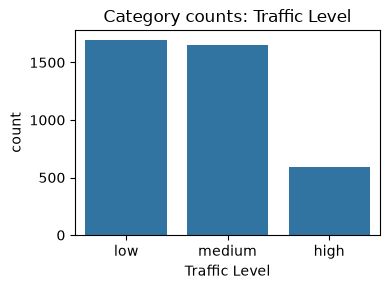

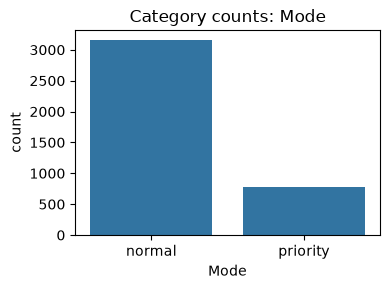

In [8]:
numeric_cols = ["Distance [m]", "Elevation [m]", "Cargo [kg]", "Battery Level", "Time of Day [h]", "Energy [kJ]"]
categorical_cols = ["Traffic Level", "Mode"]

for col in numeric_cols:
    plt.figure(figsize=(5, 3))
    sns.histplot(raw_train_df[col], kde=False)
    plt.title(f"Distribution: {col}")
    plt.tight_layout()
    plt.show()

for col in categorical_cols:
    plt.figure(figsize=(4, 3))
    sns.countplot(x=raw_train_df[col])
    plt.title(f"Category counts: {col}")
    plt.tight_layout()
    plt.show()


I saw that the original blueprint only analyzed individual features. To build a better prediction model, I added the following to see how these features directly impact our target `Energy [kJ]`

- Correlation Heatmap: To measure the mathematical relationship between numeric features and energy drain.

- Violin Plot: To visualize the actual energy cost of text categories like Traffic Level and Mode.

- Scatter Plots: To spot physical trends (e.g., heavy Cargo [kg] on uphill Elevation [m] routes) and outliers.

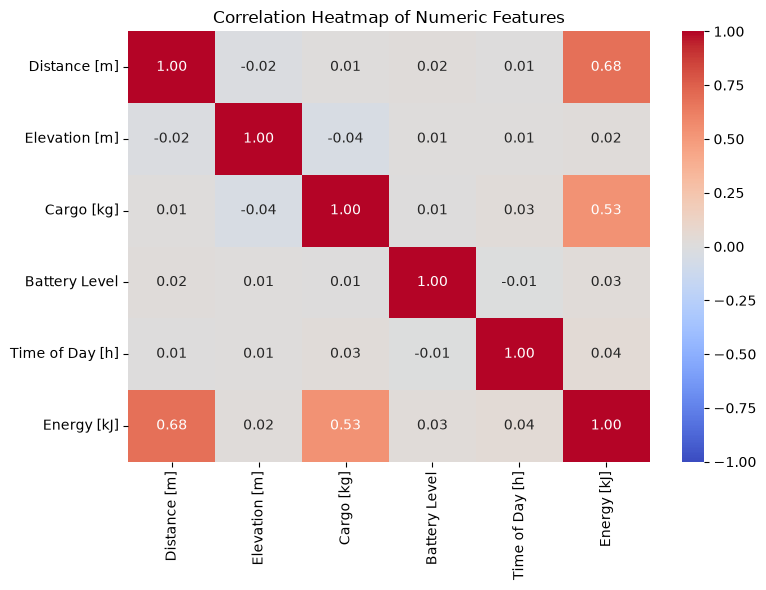

In [9]:
plt.figure(figsize=(8, 6))
correlation_matrix = raw_train_df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

C:\Users\evaca\AppData\Local\Temp\ipykernel_30936\2824458333.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=raw_train_df, x=col, y="Energy [kJ]", palette="muted", inner="quartile")


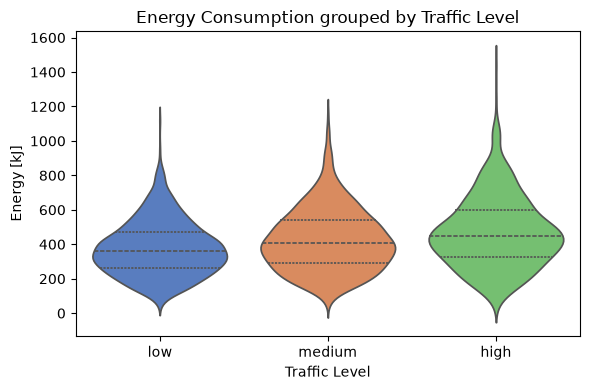

C:\Users\evaca\AppData\Local\Temp\ipykernel_30936\2824458333.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=raw_train_df, x=col, y="Energy [kJ]", palette="muted", inner="quartile")


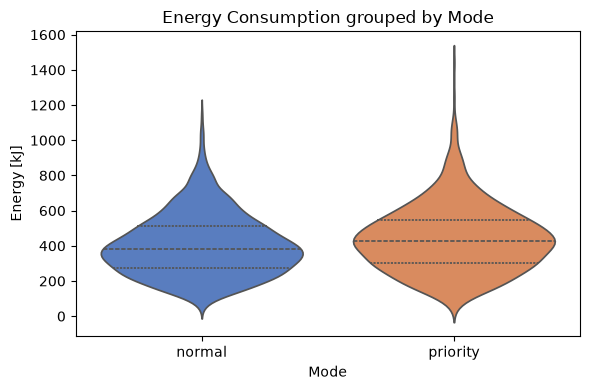

In [14]:
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.violinplot(data=raw_train_df, x=col, y="Energy [kJ]", palette="muted", inner="quartile")
    plt.title(f"Energy Consumption grouped by {col}")
    plt.tight_layout()
    plt.show()

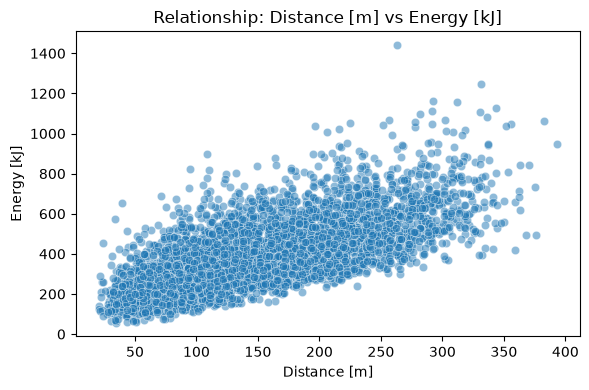

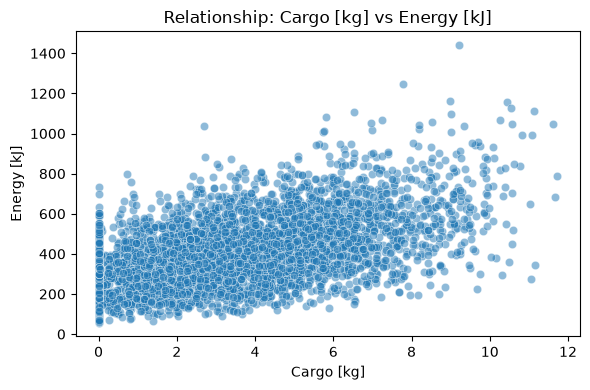

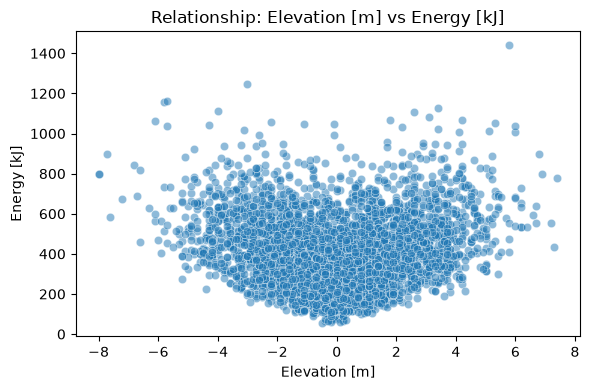

In [15]:
features_to_plot = ["Distance [m]", "Cargo [kg]", "Elevation [m]"]

for col in features_to_plot:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=raw_train_df, x=col, y="Energy [kJ]", alpha=0.5)
    plt.title(f"Relationship: {col} vs Energy [kJ]")
    plt.tight_layout()
    plt.show()

## 2. Data cleansing


In [16]:
TARGET_COLUMN = "Energy [kJ]"
ID_COLUMN = "Mission ID"
NUMERIC_COLUMNS = ["Distance [m]", "Elevation [m]", "Cargo [kg]", "battery_soc", "hour"]
CATEGORICAL_COLUMNS = ["Traffic Level", "Mode"]

I combined the imputation values into a single dictionary and replaced the for loops with one `fillna()` command to make the code cleaner and execute significantly faster by using pandas built-in optimization.

In [18]:
def fit_imputer(df_train: pd.DataFrame):
    # Create dictionary with imputation values based on training data (median for numeric, mode for categorical)
    median_values = {col: df_train[col].median() for col in NUMERIC_COLUMNS}
    mode_values = {col: df_train[col].mode(dropna=True).iloc[0] for col in CATEGORICAL_COLUMNS}
    master_impute_dict = {**median_values, **mode_values}

    # Define a function that applies the imputation to any given DataFrame
    def apply_imputation(df: pd.DataFrame) -> pd.DataFrame:
        # IMPROVEMENT: Use pandas to fill all columns at once without a loop
        return df.fillna(value=master_impute_dict)

    return apply_imputation


## 3. Feature engineering


In [24]:
def fit_preprocessor(df_train: pd.DataFrame):
    impute_fn = fit_imputer(df_train)

    def transform(df: pd.DataFrame) -> pd.DataFrame:
        df_clean = impute_fn(df)

        # 1. Total System Weight (Assuming a 50kg base chassis weight)
        df_clean["Total Weight [kg]"] = df_clean["Cargo [kg]"] + 50
        
        # 2. Uphill Strain Index 
        # .clip(lower=0) turns all downhill negative numbers into 0 so we only measure uphill strain
        df_clean["Uphill Strain"] = df_clean["Elevation [m]"].clip(lower=0) * df_clean["Total Weight [kg]"]
        
        # 3. Rush Hour Flag (1 if between 9:00 and 17:00, otherwise 0)
        df_clean["Rush Hour Flag"] = df_clean["Time of Day [h]"].between(9, 17).astype(int)
        
        # 4. Traffic Escalation Scale
        # We create a new column mapping the text to an ordered 1-2-3 scale
        traffic_map = {"low": 1, "medium": 2, "high": 3}
        df_clean["Traffic Scale"] = df_clean["Traffic Level"].map(traffic_map)
        
        # 5. Traffic Jam Multiplier (Combining Rush Hour and Traffic Severity)
        df_clean["Traffic Jam Multiplier"] = df_clean["Rush Hour Flag"] * df_clean["Traffic Scale"]
        
        # C. One-Hot Encoding 
        # We keep drop_first=True to avoid the dummy variable trap!
        output_df = pd.get_dummies(df_clean, columns=CATEGORICAL_COLUMNS, drop_first=True)
        
        return output_df

    return transform